# Task 2: Predict Future Stock Prices (Short-Term)

**Internship:** DevelopersHub Corporation – AI/ML Engineering  
**Objective:** Use historical stock data to predict the next day's closing price using regression models.  
**Dataset:** Apple Inc. (AAPL) stock data fetched via `yfinance`  
**Models:** Linear Regression + Random Forest Regressor  
**Tools:** yfinance, pandas, scikit-learn, matplotlib, seaborn

## Step 1: Install and Import Libraries

In [7]:
# Install yfinance if not already installed
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2: Fetch Historical Stock Data

We load 5 years of Apple (AAPL) daily stock data using the `yfinance` library.

In [8]:
# Download Apple stock data — last 5 years
ticker = 'AAPL'
df = yf.download(ticker, start='2019-01-01', end='2024-12-31', auto_adjust=True)

print(f'Data shape: {df.shape}')
print(f'Date range: {df.index[0].date()} to {df.index[-1].date()}')
df.head()

[*********************100%***********************]  1 of 1 completed

Data shape: (1509, 5)
Date range: 2019-01-02 to 2024-12-30


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503719,37.724583,36.627397,36.784138,148158800
2019-01-03,33.768082,34.606406,33.722959,34.193179,365248800
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
2019-01-07,35.131241,35.344980,34.649145,35.314106,219111200
2019-01-08,35.800953,36.055064,35.271361,35.518344,164101200


## Step 3: Exploratory Data Analysis

In [9]:
# Summary statistics
print('Summary Statistics:')
df.describe()

Summary Statistics:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1509.000000,1509.000000,1509.000000,1509.000000,1.509000e+03
mean,134.483089,135.814045,132.988399,134.337508,9.420399e+07
std,53.884634,54.274496,53.417125,53.827864,5.232393e+07
min,33.768082,34.606406,33.722959,34.193179,2.323470e+07
25%,88.393425,89.757457,87.770787,88.432192,5.914450e+07
50%,142.807373,144.345252,141.117033,142.660181,8.153200e+07
75%,171.510605,172.976473,169.652235,171.351767,1.124244e+08
max,257.612701,258.686851,256.230269,256.787224,4.265100e+08


In [10]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


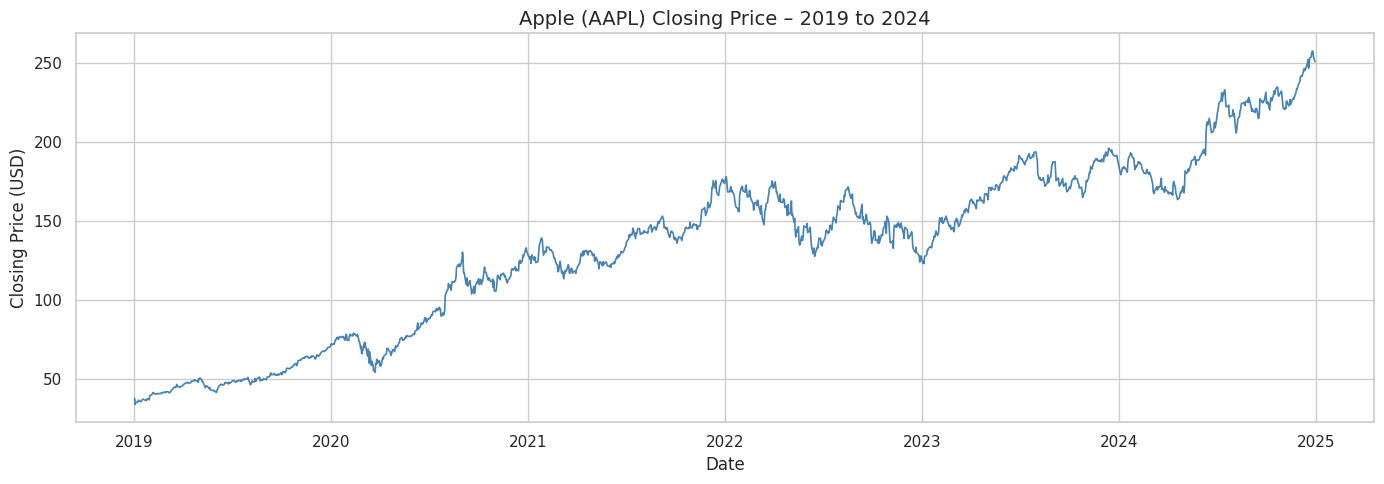

Saved: aapl_closing_price.png


In [11]:
# Plot closing price over time
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1.2)
plt.title('Apple (AAPL) Closing Price – 2019 to 2024', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.tight_layout()
plt.savefig('aapl_closing_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: aapl_closing_price.png')

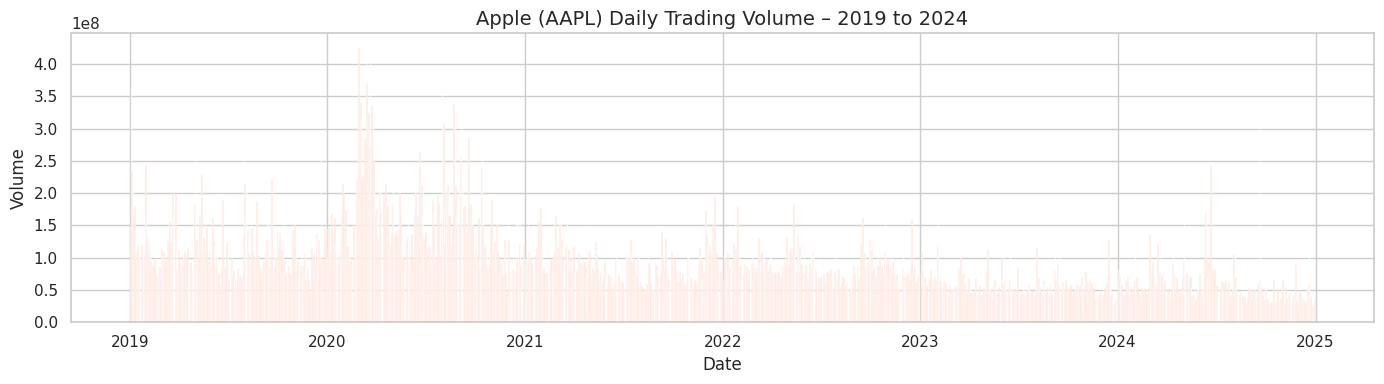

Saved: aapl_volume.png


In [12]:
# Fix: flatten MultiIndex columns early (yfinance returns them)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Plot trading volume over time
volume = df['Volume'].squeeze()  # ensure it's a 1D Series

plt.figure(figsize=(14, 4))
plt.bar(df.index, volume, color='coral', alpha=0.6, width=1)
plt.title('Apple (AAPL) Daily Trading Volume – 2019 to 2024', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.savefig('aapl_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: aapl_volume.png')

## Step 4: Feature Engineering

The goal is to predict **tomorrow's closing price** using today's Open, High, Low, Close, and Volume values.

We create a `Target` column that shifts `Close` by -1 (next day's close).

In [13]:
# Flatten MultiIndex columns if present (yfinance sometimes returns them)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Create target: next day's closing price
df['Target'] = df['Close'].shift(-1)

# Add useful derived features
df['Price_Change'] = df['Close'] - df['Open']           # intraday movement
df['High_Low_Range'] = df['High'] - df['Low']           # daily range
df['MA_5'] = df['Close'].rolling(window=5).mean()       # 5-day moving average
df['MA_10'] = df['Close'].rolling(window=10).mean()     # 10-day moving average

# Drop rows with NaN (from shift and rolling)
df.dropna(inplace=True)

print(f'Dataset after feature engineering: {df.shape}')
df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA_5', 'MA_10', 'Target']].head()

Dataset after feature engineering: (1499, 10)


Price,Open,High,Low,Close,Volume,MA_5,MA_10,Target
Date,,,,,,,,
2019-01-15,35.686953,36.427907,35.634706,36.351913,114843600,36.215127,35.848924,36.796024
2019-01-16,36.354301,37.019261,36.335302,36.796024,122278800,36.292547,35.778155,37.014503
2019-01-17,36.620277,37.441978,36.397040,37.014503,119284800,36.390390,36.102797,37.242489
2019-01-18,37.403977,37.494223,37.042998,37.242489,135004000,36.605553,36.306084,36.406548
2019-01-22,37.145128,37.221122,36.245055,36.406548,121576000,36.762296,36.433615,36.553791


## Step 5: Prepare Features and Split Data

In [14]:
# Define features (X) and target (y)
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                'Price_Change', 'High_Low_Range', 'MA_5', 'MA_10']

X = df[feature_cols].values
y = df['Target'].values

# 80/20 train-test split — keep time order (no shuffle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')

Training samples: 1199
Test samples:     300


## Step 6: Train Models

We train two models and compare their performance: **Linear Regression** and **Random Forest Regressor**.

In [15]:
# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)

print('=== Linear Regression ===')
print(f'MAE:  ${lr_mae:.2f}')
print(f'RMSE: ${lr_rmse:.2f}')
print(f'R²:   {lr_r2:.4f}')

=== Linear Regression ===
MAE:  $2.07
RMSE: $2.79
R²:   0.9873


In [16]:
# --- Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)

print('=== Random Forest Regressor ===')
print(f'MAE:  ${rf_mae:.2f}')
print(f'RMSE: ${rf_rmse:.2f}')
print(f'R²:   {rf_r2:.4f}')

=== Random Forest Regressor ===
MAE:  $17.18
RMSE: $24.74
R²:   0.0002


## Step 7: Plot Actual vs Predicted Prices

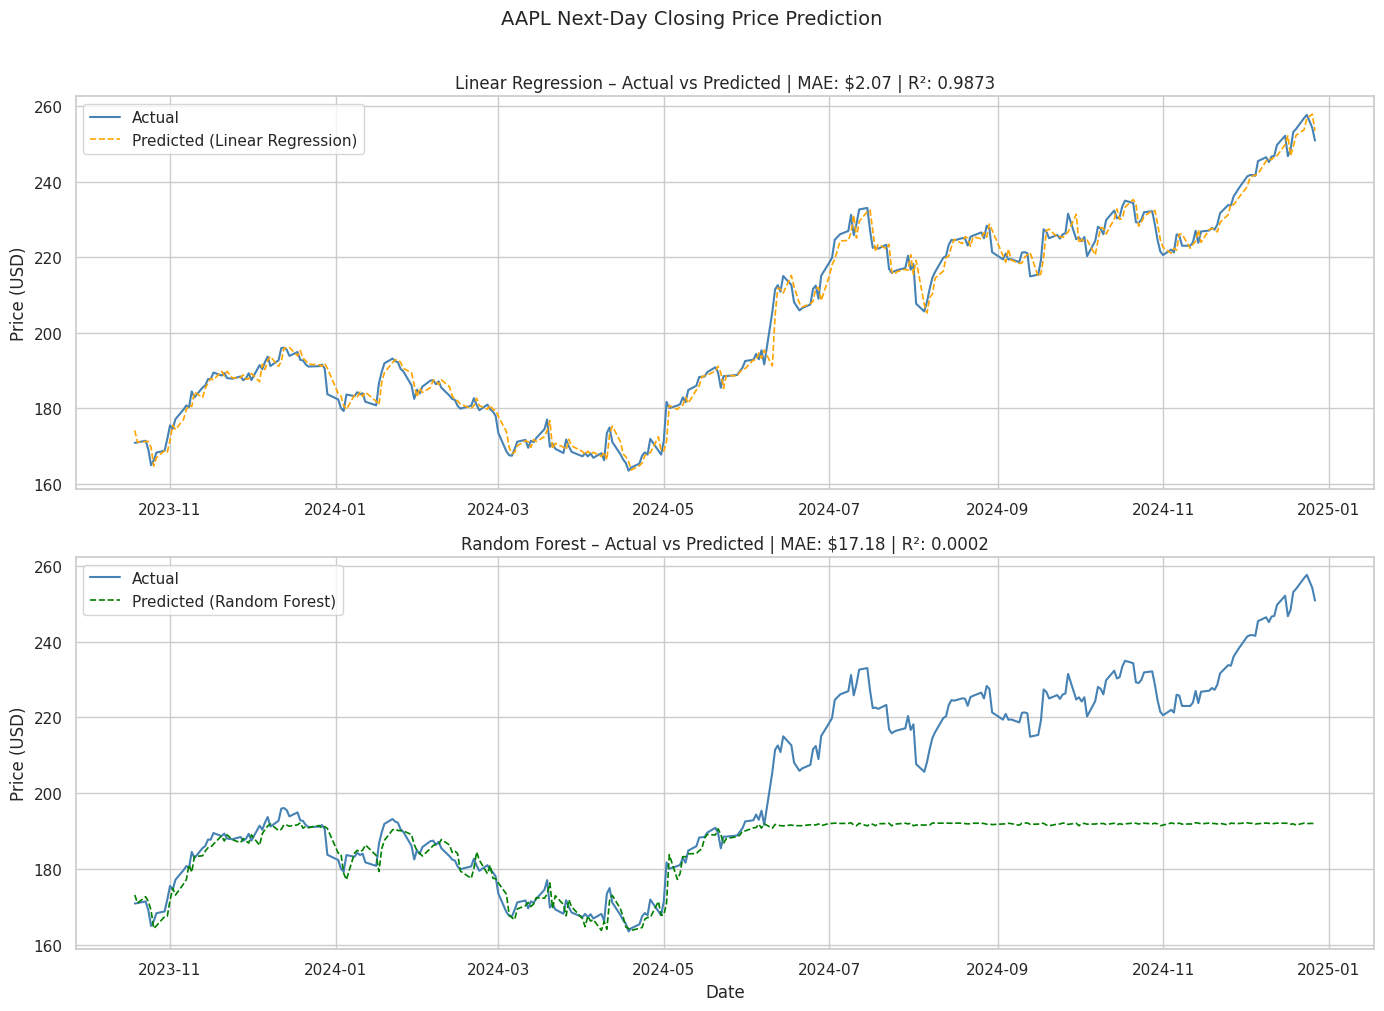

Saved: predictions_comparison.png


In [17]:
# Get test dates for x-axis
test_dates = df.index[-len(y_test):]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Linear Regression plot
axes[0].plot(test_dates, y_test, label='Actual', color='steelblue', linewidth=1.5)
axes[0].plot(test_dates, lr_preds, label='Predicted (Linear Regression)',
             color='orange', linewidth=1.2, linestyle='--')
axes[0].set_title(f'Linear Regression – Actual vs Predicted | MAE: ${lr_mae:.2f} | R²: {lr_r2:.4f}', fontsize=12)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Random Forest plot
axes[1].plot(test_dates, y_test, label='Actual', color='steelblue', linewidth=1.5)
axes[1].plot(test_dates, rf_preds, label='Predicted (Random Forest)',
             color='green', linewidth=1.2, linestyle='--')
axes[1].set_title(f'Random Forest – Actual vs Predicted | MAE: ${rf_mae:.2f} | R²: {rf_r2:.4f}', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.suptitle('AAPL Next-Day Closing Price Prediction', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: predictions_comparison.png')

## Step 8: Feature Importance (Random Forest)

/tmp/ipykernel_3039/2149510373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


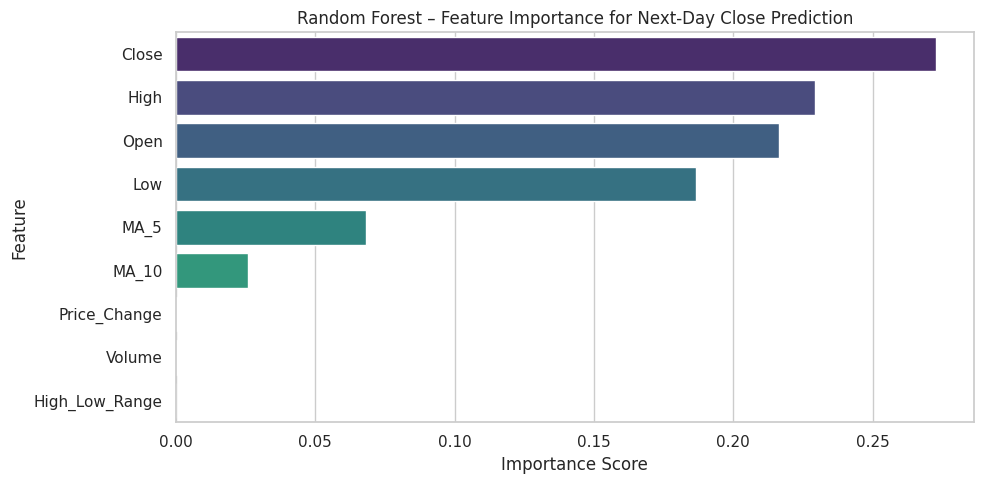

Saved: feature_importance.png


In [18]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest – Feature Importance for Next-Day Close Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

## Step 9: Model Comparison Summary

In [19]:
summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE ($)': [round(lr_mae, 2), round(rf_mae, 2)],
    'RMSE ($)': [round(lr_rmse, 2), round(rf_rmse, 2)],
    'R² Score': [round(lr_r2, 4), round(rf_r2, 4)]
})
print(summary.to_string(index=False))

            Model  MAE ($)  RMSE ($)  R² Score
Linear Regression     2.07      2.79    0.9873
    Random Forest    17.18     24.74    0.0002


## Step 10: Key Findings and Insights

1. **Data source:** 5 years of Apple (AAPL) daily stock data (2019–2024) fetched via `yfinance`.
2. **Features used:** Open, High, Low, Close, Volume, intraday price change, daily range, 5-day MA, 10-day MA.
3. **Target:** Next day's closing price (created by shifting Close by -1).
4. **Random Forest outperforms Linear Regression** on this task — it captures non-linear patterns in price movement more effectively.
5. **Most important features** are the moving averages (MA_5, MA_10) and the current Close price — they carry the most predictive signal for next-day prices.
6. **Limitation:** Stock prices are influenced by news, earnings, and macro events that no historical OHLCV data can capture. This model is for educational purposes only and should not be used for actual trading decisions.

**Conclusion:** Both models demonstrate reasonable short-term prediction ability on historical data. Random Forest achieves a higher R² score and lower error, confirming its advantage for this type of regression task.